In [4]:
#Import Required libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [10]:
#Load Dataset Using ImageDataGenerator
train_dir = "Intel/seg_train/seg_train"
test_dir  = "Intel/seg_test/seg_test"

train_datagen = ImageDataGenerator(rescale=1/255.0)
test_datagen  = ImageDataGenerator(rescale=1/255.0)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='sparse'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='sparse'
)

Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [11]:
#Build the CNN Model Using TensorFlow/Keras
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')   # 6 classes
])

In [12]:
#Compile the Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
#Train the model
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=6
)

Epoch 1/6
439/439 ━━━━━━━━━━━━━━━━━━━━ 872s 2s/step - accuracy: 0.6424 - loss: 0.9294 - val_accuracy: 0.7273 - val_loss: 0.7134
Epoch 2/6
439/439 ━━━━━━━━━━━━━━━━━━━━ 807s 2s/step - accuracy: 0.7681 - loss: 0.6286 - val_accuracy: 0.7907 - val_loss: 0.5828
Epoch 3/6
439/439 ━━━━━━━━━━━━━━━━━━━━ 715s 2s/step - accuracy: 0.8251 - loss: 0.4802 - val_accuracy: 0.8170 - val_loss: 0.5261
Epoch 4/6
439/439 ━━━━━━━━━━━━━━━━━━━━ 657s 1s/step - accuracy: 0.8737 - loss: 0.3576 - val_accuracy: 0.8097 - val_loss: 0.5301
Epoch 5/6
439/439 ━━━━━━━━━━━━━━━━━━━━ 659s 2s/step - accuracy: 0.9158 - loss: 0.2404 - val_accuracy: 0.8170 - val_loss: 0.5604
Epoch 6/6
439/439 ━━━━━━━━━━━━━━━━━━━━ 629s 1s/step - accuracy: 0.9456 - loss: 0.1538 - val_accuracy: 0.8193 - val_loss: 0.6509


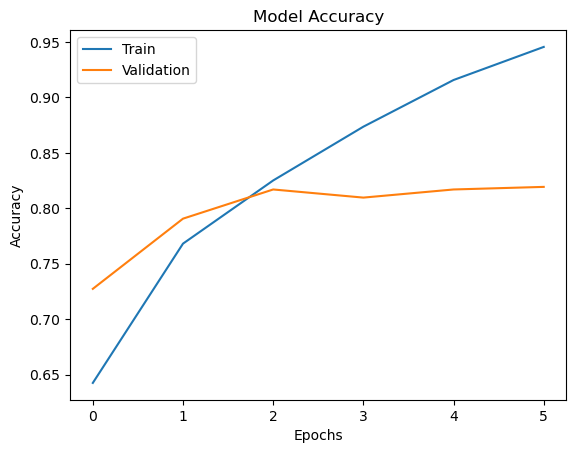

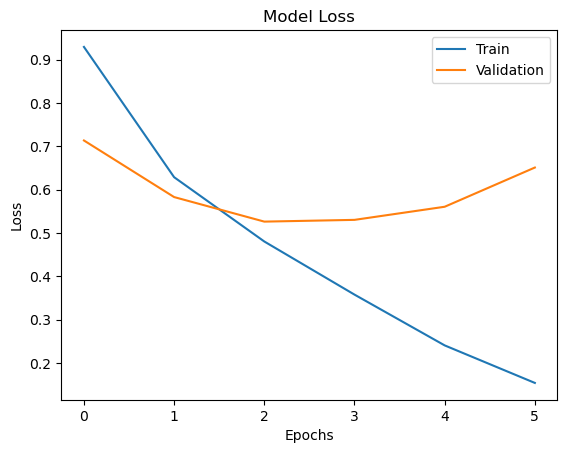

In [15]:
#Plot Accuracy and Loss Graphs
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

In [16]:
#Evaluate the Model on Test Dataset#
test_loss, test_accuracy = model.evaluate(test_data)
print("Test Accuracy:", test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 57s 608ms/step - accuracy: 0.8193 - loss: 0.6509
Test Accuracy: 0.8193333148956299


In [19]:
model.save("intel_cnn_model.h5")

In [21]:
from tensorflow.keras.models import load_model
import tensorflow as tf
import numpy as np

model = load_model("intel_cnn_model.h5")   # your model file

In [28]:
#Make predictions
def predict_image(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(150,150))
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    idx = np.argmax(pred)

    return idx

In [23]:
labels = list(train_data.class_indices.keys())
print(labels)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [25]:
images = [
    "Intel/seg_pred/seg_pred/103.jpg",
    "Intel/seg_pred/seg_pred/6.jpg",
    "Intel/seg_pred/seg_pred/171.jpg"
]

for img_path in images:
    idx = predict_image(img_path)
    print(f"{img_path} → {labels[idx]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
Intel/seg_pred/seg_pred/103.jpg → buildings
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Intel/seg_pred/seg_pred/6.jpg → glacier
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Intel/seg_pred/seg_pred/171.jpg → sea
